# Deep Learning Baseline

Emotion Intelligence Platform

This notebook will be used to develop and evaluate deep learning models for emotion classification.

In [24]:
import pandas as pd

In [25]:
train_df = pd.read_csv("../../data/processed/train.csv")
val_df = pd.read_csv("../../data/processed/validation.csv")
test_df = pd.read_csv("../../data/processed/test.csv")

In [26]:
train_df.head()

,id,split,text,text_clean,label,label_name,n_words,n_chars,has_negation
0,train_000000,train,i didnt feel humiliated,i didnt feel humiliated,0,sadness,4,23,1
1,train_000001,train,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...,0,sadness,21,108,0
2,train_000002,train,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong,3,anger,10,48,0
3,train_000003,train,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...,2,love,18,92,0
4,train_000004,train,i am feeling grouchy,i am feeling grouchy,3,anger,4,20,0


In [27]:
X_train = train_df["text_clean"]
y_train = train_df["label"]

X_val = val_df["text_clean"]
y_val = val_df["label"]

X_test = test_df["text_clean"]
y_test = test_df["label"]

In [28]:
len(X_train)

15983

In [29]:
len(X_val)

2000

In [30]:
len(X_test)

2000

In [31]:
print("Example text:", X_train.iloc[0])
print("Example label:", y_train.iloc[0])
print("Example emotion:", train_df["label_name"].iloc[0])

Example text: i didnt feel humiliated
Example label: 0
Example emotion: sadness


##  Text Vectorization

Text Vectorization converts text into numerical sequences that can be understood by the deep learning model.


In [32]:
import tensorflow as tf

In [33]:
max_tokens = 10000
sequence_length = 100

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length
)

In [34]:
vectorizer.adapt(X_train)

In [35]:
sample = X_train.iloc[0]

print("Original text:")
print(sample)

print("\nVectorized:")
print(vectorizer(sample))

Original text:
i didnt feel humiliated

Vectorized:
tf.Tensor(
[  2 140   3 686   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0], shape=(100,), dtype=int64)


##  Embedding-Based Deep Learning Model

An Embedding layer converts each word into a dense numerical vector that captures useful relationships between words.


In [36]:
vocab_size = len(vectorizer.get_vocabulary())

print("Vocabulary size:", vocab_size)

Vocabulary size: 10000


In [37]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(), dtype=tf.string),
    vectorizer,
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(6, activation="softmax")
])

In [38]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,550 (2.46 MB)

 Trainable params: 644,550 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

##  Model Training

The model is trained on the training data and evaluated on the validation data after each epoch to monitor its performance.


In [40]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train.to_numpy(), y_train.to_numpy())
).batch(32)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (X_val.to_numpy(), y_val.to_numpy())
).batch(32)

In [41]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10


C:\Users\SH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3304 - loss: 1.5923 - val_accuracy: 0.3520 - val_loss: 1.5791
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.3526 - loss: 1.5689 - val_accuracy: 0.3525 - val_loss: 1.5458
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4494 - loss: 1.4602 - val_accuracy: 0.5475 - val_loss: 1.3227
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5839 - loss: 1.1484 - val_accuracy: 0.6170 - val_loss: 0.9888
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7139 - loss: 0.8229 - val_accuracy: 0.7570 - val_loss: 0.7325
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8014 - loss: 0.6007 - val_accuracy: 0.8100 - val_loss: 0.5935
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8499 - loss: 0.4660 - val_accuracy: 0.8135 - val_loss: 0.5430
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8707 - loss: 0.3919 - val_accuracy: 0.8415 - val_

##  Model Evaluation

We evaluate the trained model on the unseen test data to measure its final performance.


In [42]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test.to_numpy(), y_test.to_numpy())
).batch(32)

In [43]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

 1/63 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8438 - loss: 0.5723

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8350 - loss: 0.4941
Test Loss: 0.49407532811164856
Test Accuracy: 0.8349999785423279


##  Classification Report and Confusion Matrix

We use the classification report and confusion matrix to evaluate the model's performance for each emotion class.


In [44]:
y_pred_probs = model.predict(test_dataset)
y_pred = y_pred_probs.argmax(axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [45]:
from sklearn.metrics import classification_report, confusion_matrix

In [46]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["sadness", "joy", "love", "anger", "fear", "surprise"]
))

              precision    recall  f1-score   support

     sadness       0.88      0.93      0.90       581
         joy       0.86      0.96      0.91       695
        love       0.73      0.45      0.55       159
       anger       0.74      0.91      0.81       275
        fear       0.80      0.62      0.70       224
    surprise       0.75      0.05      0.09        66

    accuracy                           0.83      2000
   macro avg       0.79      0.65      0.66      2000
weighted avg       0.83      0.83      0.82      2000



In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

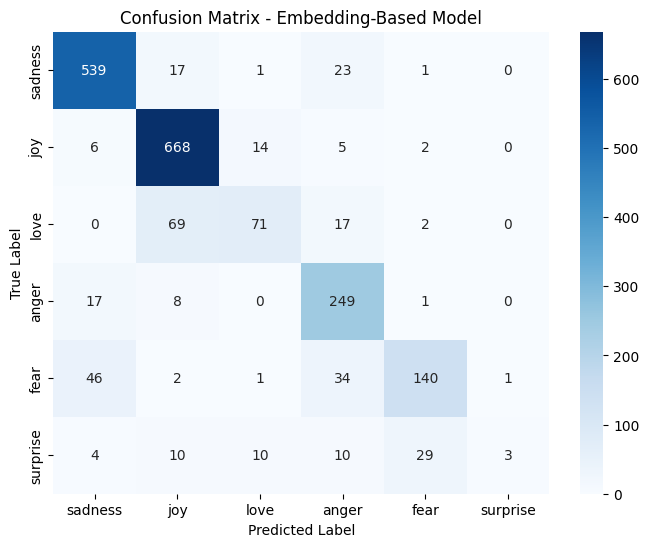

In [48]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["sadness", "joy", "love", "anger", "fear", "surprise"],
    yticklabels=["sadness", "joy", "love", "anger", "fear", "surprise"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Embedding-Based Model")
plt.show()

##  Training Curves

Training and validation curves are used to monitor the model's performance and detect overfitting during training.


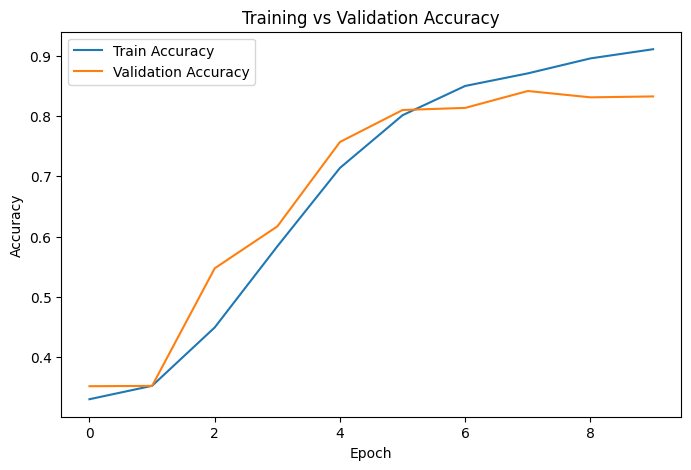

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

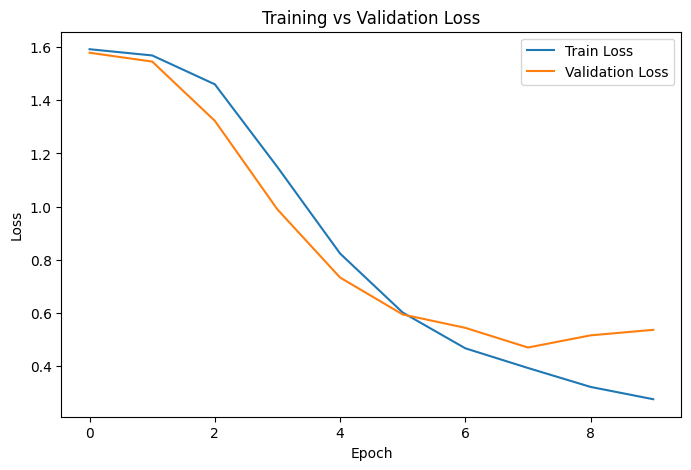

In [50]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

##  LSTM Sequence Classifier

An LSTM model is used to capture the sequential relationships between words and classify the text into emotions.


In [51]:
vocab_size = len(vectorizer.get_vocabulary())

print("Vocabulary size:", vocab_size)

Vocabulary size: 10000


In [52]:
embedding_dim = 64

In [53]:
lstm_model = tf.keras.Sequential([
    tf.keras.Input(shape=(), dtype=tf.string),
    vectorizer,

    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        mask_zero=True
    ),

    tf.keras.layers.LSTM(64),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(6, activation="softmax")
])

In [54]:
lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [55]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 677,574 (2.58 MB)

 Trainable params: 677,574 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [57]:
# learning rate
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

In [58]:
lstm_history = lstm_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[
        early_stopping,
        lr_scheduler
    ]
)

Epoch 1/15


C:\Users\SH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.5495 - loss: 1.1725 - val_accuracy: 0.7570 - val_loss: 0.6695 - learning_rate: 0.0010
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.8550 - loss: 0.4272 - val_accuracy: 0.8635 - val_loss: 0.3885 - learning_rate: 0.0010
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.9239 - loss: 0.2266 - val_accuracy: 0.8965 - val_loss: 0.3244 - learning_rate: 0.0010
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.9595 - loss: 0.1227 - val_accuracy: 0.9015 - val_loss: 0.3625 - learning_rate: 0.0010
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 73ms/step - accuracy: 0.9772 - loss: 0.0703 - val_accuracy: 0.9135 - val_loss: 0.3227 - learning_rate: 5.0000e-04
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 124ms/step - accuracy: 0.9849 - loss: 0.0475 - val_accuracy: 0.9210 - val_loss: 0.3311 - learning_rate: 5.0000e-04
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 77ms/step - accuracy: 0.9878 - los

In [59]:
lstm_test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test.to_numpy(), y_test.to_numpy())
).batch(32)

lstm_test_loss, lstm_test_accuracy = lstm_model.evaluate(
    lstm_test_dataset
)

print("LSTM Test Loss:", lstm_test_loss)
print("LSTM Test Accuracy:", lstm_test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9070 - loss: 0.2836
LSTM Test Loss: 0.28358277678489685
LSTM Test Accuracy: 0.9070000052452087


In [60]:
lstm_y_pred_probs = lstm_model.predict(lstm_test_dataset)

lstm_y_pred = lstm_y_pred_probs.argmax(axis=1)

print(classification_report(
    y_test,
    lstm_y_pred,
    target_names=[
        "sadness",
        "joy",
        "love",
        "anger",
        "fear",
        "surprise"
    ]
))

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step
              precision    recall  f1-score   support

     sadness       0.96      0.95      0.95       581
         joy       0.93      0.94      0.93       695
        love       0.87      0.69      0.77       159
       anger       0.87      0.92      0.89       275
        fear       0.86      0.90      0.88       224
    surprise       0.66      0.71      0.69        66

    accuracy                           0.91      2000
   macro avg       0.86      0.85      0.85      2000
weighted avg       0.91      0.91      0.91      2000



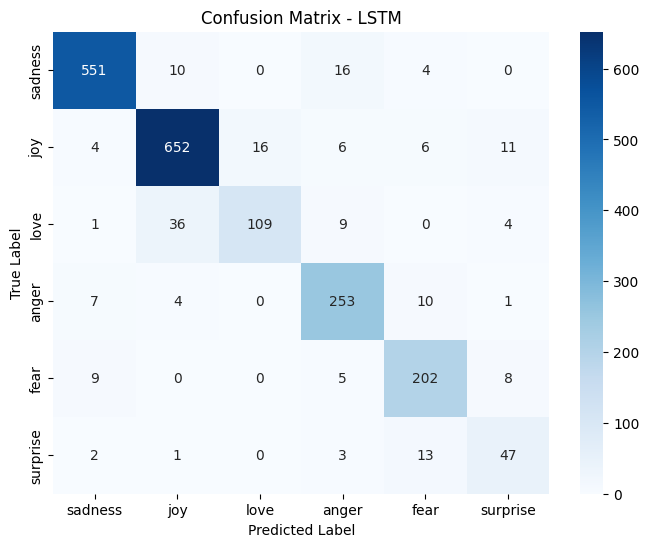

In [61]:
lstm_cm = confusion_matrix(y_test, lstm_y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    lstm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "sadness",
        "joy",
        "love",
        "anger",
        "fear",
        "surprise"
    ],
    yticklabels=[
        "sadness",
        "joy",
        "love",
        "anger",
        "fear",
        "surprise"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - LSTM")
plt.show()

##  Model Comparison

We compare the performance of the classical NLP model, embedding-based model, and LSTM using their test performance.


In [62]:
comparison = pd.DataFrame({
    "Model": [
        "Classical ML - LinearSVM",
        "Embedding MLP",
        "LSTM"
    ],
    "Accuracy": [
        0.8355,
        test_accuracy,
        lstm_test_accuracy
    ]
})

comparison

,Model,Accuracy
0,Classical ML - LinearSVM,0.8355
1,Embedding MLP,0.8350
2,LSTM,0.9070


In [72]:
%pip install "huggingface_hub<0.24.0" --force-reinstall

  Using cached packaging-26.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl.metadata (2.4 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached tqdm-4.70.1-py3-none-any.whl.metadata (57 kB)
  Using cached typing_extensions-4.16.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached colorama-0.4.6-py2.py3-none-any.whl.metadata (17 kB)
  Using cached charset_normalizer-3.5.1-cp311-cp311-win_amd64.whl.metadata (46 kB)
  Using cached idna-3.19-py3-none-any.whl.metadata (9.2 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
Using cached packaging-26.3-py3-none-any.whl (129 kB)
Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl (158 kB)
Using cached tqdm-4.70.1-py3-none-any.whl (80 kB)
Using cached typing_extensions-4.16.0-py3-none-any.whl (45 kB)
Using cached requests-2.34.2-py3-none-any.whl (73 kB)
Using cached certifi-2026.7.22-py3-none-any.whl (136 kB)
Using cached charset_normalizer-3.5.1-cp311

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
mlflow 3.14.0 requires pyarrow<25,>=4.0.0, but you have pyarrow 25.0.1 which is incompatible.
pyppeteer 2.0.0 requires urllib3<2.0.0,>=1.25.8, but you have urllib3 2.8.0 which is incompatible.
sentence-transformers 6.0.1 requires huggingface-hub<2.0.0,>=1.3.0, but you have huggingface-hub 0.23.5 which is incompatible.
streamlit 1.45.0 requires packaging<25,>=20, but you have packaging 26.3 which is incompatible.
transformers 5.17.0 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.23.5 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\SH\AppData\Loc

In [73]:
import bertopic
print(bertopic.__version__)

ImportError: cannot import name 'is_offline_mode' from 'huggingface_hub' (C:\Users\SH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\__init__.py)

In [ ]:
# Use the cleaned training text
topic_text = X_train.copy()

# Remove URLs and HTML tags
topic_text = (
    topic_text
    .str.replace(r"http\S+|www\S+", "", regex=True)
    .str.replace(r"<.*?>", "", regex=True)
    .str.strip()
)

print("Number of documents:", len(topic_text))
print(topic_text.head())

Number of documents: 15983
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text_clean, dtype: str


In [ ]:
topic_text = X_train.copy()

In [ ]:
from bertopic import BERTopic

topic_model = BERTopic(
    language="english",
    min_topic_size=50,
    verbose=True
)

topics, probabilities = topic_model.fit_transform(
    topic_text.tolist()
)

2026-09-15 23:07:59,932 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 500/500 [01:17<00:00,  6.42it/s]
2026-09-15 23:09:30,388 - BERTopic - Embedding - Completed ✓
2026-09-15 23:09:30,390 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-15 23:10:22,529 - BERTopic - Dimensionality - Completed ✓
2026-09-15 23:10:22,532 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-15 23:10:24,546 - BERTopic - Cluster - Completed ✓
2026-09-15 23:10:24,567 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-15 23:10:25,061 - BERTopic - Representation - Completed ✓


In [ ]:
topic_info = topic_model.get_topic_info()

topic_info.head(15)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,8061,-1_feel_and_the_to,"[feel, and, the, to, feeling, that, of, my, in...",[i sometimes feel doomed that the way my life ...
1,0,676,0_wear_it_and_cute,"[wear, it, and, cute, hair, ugly, look, feel, ...","[i really feel cute when i wear them, i decide..."
2,1,485,1_blessed_thankful_to_happy,"[blessed, thankful, to, happy, so, joyful, fee...",[i feel like we have so much to be thankful fo...
3,2,406,2_her_she_shes_was,"[her, she, shes, was, that, to, and, with, fee...",[i haven t seen her since they broke up but no...
4,3,310,3_passionate_school_students_about,"[passionate, school, students, about, class, t...","[i feel most passionate about, i feel more pas..."
5,4,290,4_eat_eating_weight_delicious,"[eat, eating, weight, delicious, food, sweet, ...",[i always feel pressured to act normal with my...
6,5,267,5_mother_mom_baby_my,"[mother, mom, baby, my, had, pregnant, her, wh...","[i feel so blessed just to be her mom, i start..."
7,6,264,6_him_he_his_me,"[him, he, his, me, to, was, with, that, and, how]",[i told him that what he did was very stupid o...
8,7,257,7_god_divine_church_the,"[god, divine, church, the, that, and, of, in, ...",[i trust though it may take more courage than ...
9,8,188,8_artistic_art_talented_creative,"[artistic, art, talented, creative, inspired, ...","[im feeling artistic google art project, im fe..."


In [ ]:
for topic_id in topic_info["Topic"].head(10):
    if topic_id != -1:
        print(f"\nTopic {topic_id}:")
        print(topic_model.get_topic(topic_id))


Topic 0:
[('wear', np.float64(0.016336882000325886)), ('it', np.float64(0.015625829498401737)), ('and', np.float64(0.013859269689864857)), ('cute', np.float64(0.013710465128342671)), ('hair', np.float64(0.013663962619092272)), ('ugly', np.float64(0.013578173120280264)), ('look', np.float64(0.013559033587023931)), ('feel', np.float64(0.013553329679891549)), ('the', np.float64(0.013263706501852292)), ('my', np.float64(0.013174385338945306))]

Topic 1:
[('blessed', np.float64(0.035782370376841226)), ('thankful', np.float64(0.03190926127038084)), ('to', np.float64(0.017561647170449005)), ('happy', np.float64(0.016966717238885022)), ('so', np.float64(0.016632843736550346)), ('joyful', np.float64(0.016311931776844524)), ('feel', np.float64(0.016265124753554287)), ('and', np.float64(0.016167301141885557)), ('for', np.float64(0.016141054574548973)), ('that', np.float64(0.01548242860140086))]

Topic 2:
[('her', np.float64(0.09327364197969414)), ('she', np.float64(0.07209538884327092)), ('shes'

In [ ]:
topic_df = X_train.to_frame(name="text").copy()

topic_df["topic"] = topics
topic_df["emotion"] = y_train.values
topic_df["emotion_name"] = topic_df["emotion"].map({
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
})

topic_df.head()

,text,topic,emotion,emotion_name
0,i didnt feel humiliated,-1,0,sadness
1,i can go from feeling so hopeless to so damned...,14,0,sadness
2,im grabbing a minute to post i feel greedy wrong,-1,3,anger
3,i am ever feeling nostalgic about the fireplac...,-1,2,love
4,i am feeling grouchy,-1,3,anger


In [ ]:
emotion_topic_matrix = pd.crosstab(
    topic_df["emotion_name"],
    topic_df["topic"]
)

emotion_topic_matrix

topic,-1,0,1,2,3,4,5,6,7,8,...,48,49,50,51,52,53,54,55,56,57
emotion_name,,,,,,,,,,,,,,,,,,,,,
anger,1053,46,8,79,23,27,35,64,20,6,...,29,6,5,2,0,0,4,42,3,2
fear,1026,54,12,45,37,19,28,40,30,6,...,27,1,2,3,0,44,0,2,5,0
joy,2644,335,334,113,150,138,73,54,115,153,...,1,38,34,26,1,6,39,3,17,4
love,662,54,84,46,40,33,23,26,25,8,...,0,13,9,20,0,0,2,0,3,0
sadness,2358,171,26,105,56,64,98,70,57,12,...,2,1,6,6,55,4,8,5,19,44
surprise,318,16,21,18,4,9,10,10,10,3,...,0,0,2,0,0,2,1,0,4,1


In [ ]:
emotion_topic_matrix = pd.crosstab(
    topic_df["emotion_name"],
    topic_df["topic"]
)

matrix = emotion_topic_matrix.drop(
    columns=-1,
    errors="ignore"
)

top_topics = (
    matrix.sum(axis=0)
    .sort_values(ascending=False)
    .head(10)
    .index
)

matrix_top = matrix[top_topics]

matrix_percent = matrix_top.div(
    matrix_top.sum(axis=1),
    axis=0
) * 100

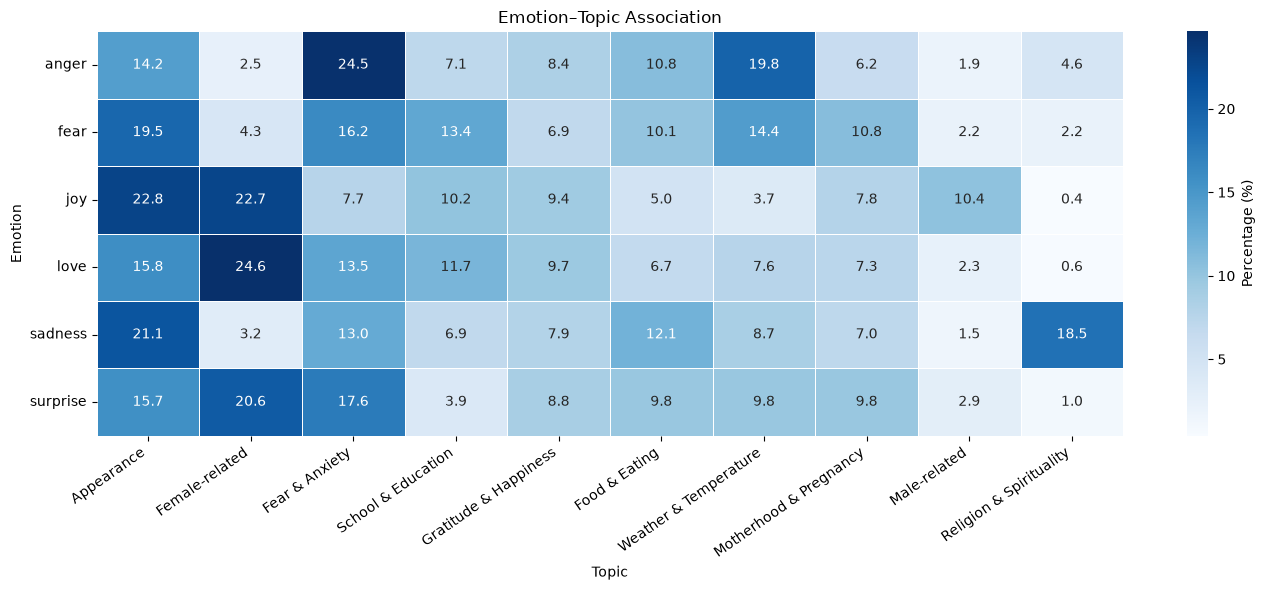

In [ ]:
topic_names = {
    0: "Appearance",
    1: "Female-related",
    2: "Fear & Anxiety",
    3: "School & Education",
    4: "Gratitude & Happiness",
    5: "Food & Eating",
    6: "Weather & Temperature",
    7: "Motherhood & Pregnancy",
    8: "Male-related",
    9: "Religion & Spirituality"
}

matrix_named = matrix_percent.rename(columns=topic_names)

plt.figure(figsize=(14, 6))

sns.heatmap(
    matrix_named,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Percentage (%)"}
)

plt.xlabel("Topic")
plt.ylabel("Emotion")
plt.title("Emotion–Topic Association")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Fear is strongly associated with the Fear & Anxiety topic, where Topic 2 accounts for 49.3% of fear-related texts.


### Joy shows a relatively strong association with the Appearance topic (22.7%), while sadness has a similar association (22.8%).

##  Priority Score

A priority score is created by combining the predicted emotion, discovered topic, and business rules.

Higher scores indicate reviews that may require greater attention or faster response.

In [ ]:
topic_info = topic_model.get_topic_info()

topic_info[["Topic", "Count", "Name"]].head(20)

,Topic,Count,Name
0,-1,8061,-1_feel_and_the_to
1,0,676,0_wear_it_and_cute
2,1,485,1_blessed_thankful_to_happy
3,2,406,2_her_she_shes_was
4,3,310,3_passionate_school_students_about
5,4,290,4_eat_eating_weight_delicious
6,5,267,5_mother_mom_baby_my
7,6,264,6_him_he_his_me
8,7,257,7_god_divine_church_the
9,8,188,8_artistic_art_talented_creative


In [ ]:
topic_names = {
    0: "Appearance",
    1: "Female-related",
    2: "Fear & Anxiety",
    3: "School & Education",
    4: "Gratitude & Happiness",
    5: "Food & Eating",
    6: "Weather & Temperature",
    7: "Motherhood & Pregnancy",
    8: "Male-related",
    9: "Religion & Spirituality",
    10: "Shame & Guilt",
    11: "Art & Creativity",
    12: "Books & Reading",
    13: "Web Content",
    14: "Blogging",
    15: "Intelligence & Self-perception",
    16: "Hopelessness & Depression",
    17: "Energy & Fatigue",
    18: "Music & Songs"
}

topic_df["topic_name"] = topic_df["topic"].map(topic_names)

In [ ]:
emotion_weight = {
    "anger": 3,
    "fear": 3,
    "sadness": 2,
    "surprise": 1,
    "love": 1,
    "joy": 0
}

In [ ]:
topic_weight = {
    "Appearance": 1,
    "Female-related": 1,
    "Fear & Anxiety": 3,
    "School & Education": 1,
    "Gratitude & Happiness": 0,
    "Food & Eating": 1,
    "Weather & Temperature": 1,
    "Motherhood & Pregnancy": 2,
    "Male-related": 1,
    "Religion & Spirituality": 1,
    "Shame & Guilt": 3,
    "Art & Creativity": 1,
    "Books & Reading": 1,
    "Web Content": 1,
    "Blogging": 1,
    "Intelligence & Self-perception": 2,
    "Hopelessness & Depression": 3,
    "Energy & Fatigue": 2,
    "Music & Songs": 1
}

In [ ]:
topic_df["emotion_score"] = (
    topic_df["emotion_name"]
    .map(emotion_weight)
    .fillna(0)
)

topic_df["topic_score"] = (
    topic_df["topic_name"]
    .map(topic_weight)
    .fillna(0)
)

topic_df["priority_score"] = (
    topic_df["emotion_score"]
    + topic_df["topic_score"]
)

In [ ]:
def priority_level(score):
    if score >= 5:
        return "High"
    elif score >= 3:
        return "Medium"
    else:
        return "Low"


topic_df["priority"] = topic_df["priority_score"].apply(priority_level)

In [ ]:
topic_df[
    [
        "text",
        "emotion_name",
        "topic_name",
        "emotion_score",
        "topic_score",
        "priority_score",
        "priority"
    ]
].head(20)

,text,emotion_name,topic_name,emotion_score,topic_score,priority_score,priority
0,i didnt feel humiliated,sadness,NaN,2,0.0,2.0,Low
1,i can go from feeling so hopeless to so damned...,sadness,Blogging,2,1.0,3.0,Medium
2,im grabbing a minute to post i feel greedy wrong,anger,NaN,3,0.0,3.0,Medium
3,i am ever feeling nostalgic about the fireplac...,love,NaN,1,0.0,1.0,Low
4,i am feeling grouchy,anger,NaN,3,0.0,3.0,Medium
5,ive been feeling a little burdened lately wasn...,sadness,NaN,2,0.0,2.0,Low
6,ive been taking or milligrams or times recomme...,surprise,NaN,1,0.0,1.0,Low
7,i feel as confused about life as a teenager or...,fear,NaN,3,0.0,3.0,Medium
8,i have been with petronas for years i feel tha...,joy,NaN,0,0.0,0.0,Low
9,i feel romantic too,love,NaN,1,0.0,1.0,Low


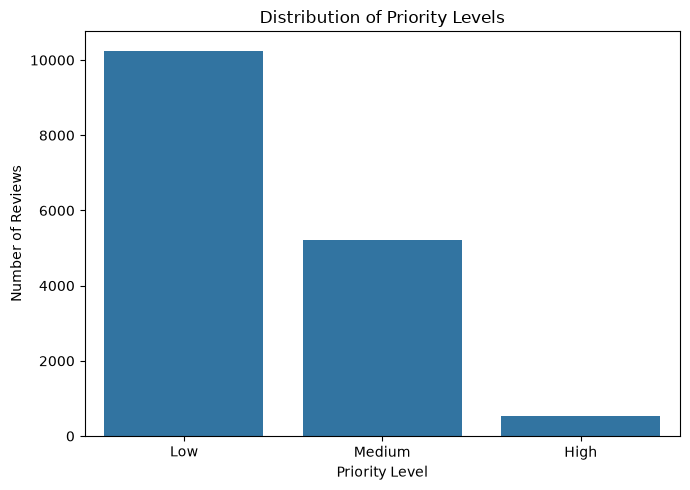

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=topic_df,
    x="priority",
    order=["Low", "Medium", "High"]
)

plt.xlabel("Priority Level")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Priority Levels")

plt.tight_layout()
plt.show()

##  Human Review Sampling

A sample of high-priority reviews is selected for manual human review.
This helps validate whether the assigned emotions, topics, and priority levels are reasonable.

In [ ]:
high_priority_reviews = topic_df[
    topic_df["priority"] == "High"
]

print("Number of high-priority reviews:", len(high_priority_reviews))

Number of high-priority reviews: 524


In [ ]:
sample_reviews = high_priority_reviews.sample(
    n=min(20, len(high_priority_reviews)),
    random_state=42
)

sample_reviews[
    [
        "text",
        "emotion_name",
        "topic_name",
        "priority_score",
        "priority"
    ]
]

,text,emotion_name,topic_name,priority_score,priority
9483,i hit the ground i feel daddy let go completel...,fear,Hopelessness & Depression,6.0,High
13574,i then wonder if the girl does want to marry m...,sadness,Fear & Anxiety,5.0,High
116,i feel all of this just from her eyes not from...,sadness,Fear & Anxiety,5.0,High
5620,im feeling very frustrated with my novel in pr...,anger,Shame & Guilt,6.0,High
2548,ive been feeling a little bit anxious of late ...,fear,Motherhood & Pregnancy,5.0,High
12314,i reconciled and life goes on as does marriage...,sadness,Fear & Anxiety,5.0,High
15961,i remember waking up feeling anxious and excit...,fear,Motherhood & Pregnancy,5.0,High
15012,i think that we must continue to seek each oth...,anger,Motherhood & Pregnancy,5.0,High
3769,i feel utterly devastated that she must go thr...,sadness,Fear & Anxiety,5.0,High
4594,ive got all those books and i feel reluctant t...,fear,Shame & Guilt,6.0,High


In [ ]:
sample_reviews["human_label"] = ""

In [ ]:
sample_reviews[
    [
        "text",
        "emotion_name",
        "topic_name",
        "priority_score",
        "priority",
        "human_label"
    ]
]

,text,emotion_name,topic_name,priority_score,priority,human_label
9483,i hit the ground i feel daddy let go completel...,fear,Hopelessness & Depression,6.0,High,
13574,i then wonder if the girl does want to marry m...,sadness,Fear & Anxiety,5.0,High,
116,i feel all of this just from her eyes not from...,sadness,Fear & Anxiety,5.0,High,
5620,im feeling very frustrated with my novel in pr...,anger,Shame & Guilt,6.0,High,
2548,ive been feeling a little bit anxious of late ...,fear,Motherhood & Pregnancy,5.0,High,
12314,i reconciled and life goes on as does marriage...,sadness,Fear & Anxiety,5.0,High,
15961,i remember waking up feeling anxious and excit...,fear,Motherhood & Pregnancy,5.0,High,
15012,i think that we must continue to seek each oth...,anger,Motherhood & Pregnancy,5.0,High,
3769,i feel utterly devastated that she must go thr...,sadness,Fear & Anxiety,5.0,High,
4594,ive got all those books and i feel reluctant t...,fear,Shame & Guilt,6.0,High,


In [74]:
# Save Embedding-based model
model.save("../../models/embedding_model.h5")
print("✓ Saved embedding_model.h5")

# Save LSTM model  
lstm_model.save("../../models/lstm_model.h5")
print("✓ Saved lstm_model.h5")

✓ Saved embedding_model.h5
✓ Saved lstm_model.h5
